In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input # VGG16 專用的預處理
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
import os

# 檢查是否有 GPU (可選，但強烈建議)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  1


In [ ]:
# --- 1. 設定你的資料夾路徑 ---
# !! 請在這裡填入你從 Colab 複製的「正確路徑」!!
base_dir = "/content/drive/MyDrive/data1" # <--- 範例路徑，請修改成你自己的
# ------------------------------------

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# (可選) 加入這行來檢查路徑是否存在
if not os.path.exists(train_dir):
    print(f"!! 警告：找不到訓練資料夾，請再次確認 base_dir 路徑是否正確 !!")
    print(f"嘗試尋找的路徑: {train_dir}")
else:
    print(f"成功找到訓練資料夾: {train_dir}")

# --- 2. 設定模型參數 ---
IMG_SIZE = 224
BATCH_SIZE = 200
EPOCHS = 15

成功找到訓練資料夾: /content/drive/MyDrive/data1/train


In [ ]:
# --- 1. 載入訓練資料 ---
# Keras 會自動把 'cat' 標為 0, 'dog' 標為 1 (或反過來，順序不重要)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE), # 自動把所有圖片縮放到 224x224
    batch_size=BATCH_SIZE,
    label_mode='binary' # 因為是二元分類 (貓 vs 狗), 標籤是 0 或 1
)

# --- 2. 載入驗證資料 ---
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# 顯示 Keras 幫我們分的類別
class_names = train_dataset.class_names
print(f"辨識到的類別: {class_names}")

# --- 3. 建立 VGG16 專用的預處理函數 ---
# VGG16 對輸入的圖片有特定的要求 (例如顏色的範圍)，我們用它內建的函數
def preprocess_vgg(image, label):
    image = preprocess_input(image) # 使用 VGG16 的預處理
    return image, label

# --- 4. 將預處理函數應用到資料集 ---
train_dataset = train_dataset.map(preprocess_vgg)
validation_dataset = validation_dataset.map(preprocess_vgg)

# --- 5. (可選) 優化資料讀取效能 ---
# .cache(): 把資料暫存在記憶體，加快讀取
# .prefetch(): 讓 GPU 在訓練時，CPU 可以先準備下一批資料
train_dataset = train_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 76 files belonging to 2 classes.
Found 131 files belonging to 2 classes.
辨識到的類別: ['key', 'phone']


In [ ]:
base_model = VGG16(
    weights='imagenet',          # 使用在 ImageNet 上預訓練好的權重
    include_top=False,           # !!重點: 不載入最上面的分類層
    input_shape=(IMG_SIZE, IMG_SIZE, 3) # 告訴他我們的圖片長相
)

# --- 2. 凍結 "專家" 的權重 ---
# 我們不希望在訓練中動到他已經學好的知識
base_model.trainable = False

# --- 3. 建立我們自己的 "決策層" ---
# 我們要把它接在 VGG16 專家的後面

# (1) 定義模型的輸入 (就是一張 224x224x3 的圖片)
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# (2) 讓圖片先通過 VGG16 專家
x = base_model(inputs, training=False) # training=False 確保 VGG16 在凍結模式

# (3) VGG16 輸出的特徵圖通常是多維的，我們要把它 "壓平"
x = layers.GlobalAveragePooling2D()(x) # 這是一種比 Flatten 更好的壓平方式

# (4) 加上一個我們自己的全連接層 (當作緩衝)
x = layers.Dense(128, activation='relu')(x)

# (5) 加上一個 Dropout 層，防止過擬合 (隨機丟掉 20% 的神經元)
x = layers.Dropout(0.2)(x)

# (6) 建立最終的輸出層
# 只需要 1 個神經元，用 sigmoid 活化函數
# sigmoid 會輸出一个 0 到 1 之間的機率值 (例如 0.1=貓, 0.9=狗)
outputs = layers.Dense(1, activation='sigmoid')(x)

# --- 4. 把 VGG16 專家和我們的新決策層 "組裝" 起來 ---
models = Model(inputs, outputs)

# --- 5. 看看我們組裝好的模型長什麼樣 ---
models.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
models.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print("開始訓練模型...")

history = models.fit(
    train_dataset,
    epochs=EPOCHS, # 總共要訓練 10 輪
    validation_data=validation_dataset # 每一輪結束後，都用驗證集評估一下
)

print("訓練完成！")

開始訓練模型...
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 120s 120s/step - accuracy: 0.4474 - loss: 3.6676 - val_accuracy: 0.3740 - val_loss: 1.2513
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4211 - loss: 1.7634 - val_accuracy: 0.6107 - val_loss: 1.0420
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6447 - loss: 0.8363 - val_accuracy: 0.6794 - val_loss: 0.6736
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7632 - loss: 0.4688 - val_accuracy: 0.8702 - val_loss: 0.3390
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9342 - loss: 0.2138 - val_accuracy: 0.9160 - val_loss: 0.1875
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0314 - val_accuracy: 0.9160 - val_loss: 0.1237
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9868 - loss: 0.0422 - val_accuracy: 0.9542 - val_loss: 0.0889
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 0.9695 - val_loss: 0.0710
Ep

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28310 (\N{CJK UNIFIED IDEOGRAPH-6E96}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas

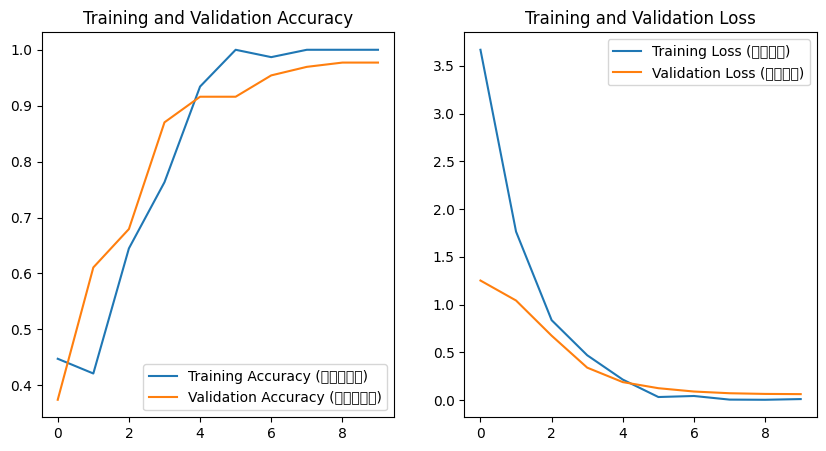

In [ ]:
# 提取訓練過程中的準確率和損失值
acc = history.history['accuracy']
val_acc = history.history['val_accuracy'] # Corrected key
loss = history.history['loss']
val_loss = history.history['val_loss'] # Corrected key

epochs_range = range(EPOCHS)

# --- 1. 畫出準確率 (Accuracy) ---
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy (訓練準確率)')
plt.plot(epochs_range, val_acc, label='Validation Accuracy (驗證準確率)')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# --- 2. 畫出損失值 (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss (訓練損失)')
plt.plot(epochs_range, val_loss, label='Validation Loss (驗證損失)')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

# 顯示圖表
plt.show()

In [ ]:
# --- 1. 定義測試集路徑和參數 ---
test_dir = "/content/drive/MyDrive/data1/test" # 你的測試集根目錄

# 注意：你的 test 資料夾結構似乎與 train/val 不同。
# train/val 結構: data/train/cat, data/train/dog
# 你的 test 結構: data/test/ (圖片直接放在這裡, 沒有 cat/dog 子資料夾)
#
# 如果你的 test 資料夾結構是這樣:
# /data/test/
#   |- 36.jpg
#   |- 37.jpg
#   |- ...
#
# 我們需要使用不同的方式來載入，避免 Keras 預期有子資料夾。

# 假設你的測試集圖片是直接放在 test_dir 下，且你只需要預測結果 (不需要真實標籤)

import glob
# 獲取所有 JPG 圖片的路徑列表
test_image_paths = glob.glob(os.path.join(test_dir, "*.jpg"))
# 你可能需要根據你的實際檔案類型調整，例如：glob.glob(os.path.join(test_dir, "*.*"))

if not test_image_paths:
    print(f"警告：在 {test_dir} 中找不到任何 .jpg 圖片檔案。請檢查路徑和副檔名。")
else:
    print(f"找到 {len(test_image_paths)} 張測試圖片，開始批量預測...")

    # --- 2. 批量載入、預處理與預測 ---

    # 用來儲存預測結果
    results = {}

    # 逐一處理每張圖片
    for i, test_image_path in enumerate(test_image_paths):
        try:
            # 載入並縮放圖片
            img = load_img(test_image_path, target_size=(IMG_SIZE, IMG_SIZE))
            img_array = img_to_array(img) # 轉成數字陣列
            img_array = np.expand_dims(img_array, axis=0) # 增加 batch 維度
            img_array = preprocess_input(img_array) # VGG16 預處理

            # 進行預測
            prediction = models.predict(img_array, verbose=0) # verbose=0 讓輸出更乾淨
            score = prediction[0][0] # 取得機率值

            # 解讀結果 (假設 class_names[0] = 'cat', class_names[1] = 'dog')
            predicted_class_index = 1 if score > 0.5 else 0
            predicted_label = class_names[predicted_class_index]
            confidence = score if predicted_class_index == 1 else (1 - score)

            # 儲存結果
            results[os.path.basename(test_image_path)] = {
                'prediction': predicted_label,
                'confidence': float(confidence)
            }

            # 打印進度 (每 50 張打印一次)
            if (i + 1) % 50 == 0:
                print(f"已處理 {i + 1} / {len(test_image_paths)} 張圖片...")

        except Exception as e:
            results[os.path.basename(test_image_path)] = {
                'prediction': 'Error',
                'confidence': 0.0,
                'message': str(e)
            }
            # print(f"處理圖片 {test_image_path} 時發生錯誤: {e}")

    # --- 3. 輸出所有結果 ---
    print("\n--- 所有測試集圖片預測結果 ---")
    dog_count = 0
    cat_count = 0

    for filename, res in results.items():
        if res['prediction'] == class_names[1]:
            dog_count += 1
            print(f"檔案: {filename} -> 預測: {res['prediction']} (機率: {res['confidence']:.4f})")
        elif res['prediction'] == class_names[0]:
            cat_count += 1
            print(f"檔案: {filename} -> 預測: {res['prediction']} (機率: {res['confidence']:.4f})")
        else:
            print(f"檔案: {filename} -> 錯誤: {res['message']}")

    print("-" * 30)
    print(f"總計 {len(test_image_paths)} 張圖片： 貓 (Cat) 數量: {cat_count}, 狗 (Dog) 數量: {dog_count}")
    print("批量預測完成！")

找到 27 張測試圖片，開始批量預測...

--- 所有測試集圖片預測結果 ---
檔案: 20.jpg -> 預測: phone (機率: 1.0000)
檔案: 25.jpg -> 預測: phone (機率: 0.9710)
檔案: 23.jpg -> 預測: phone (機率: 0.9898)
檔案: 6.jpg -> 預測: key (機率: 1.0000)
檔案: 2.jpg -> 預測: key (機率: 0.9989)
檔案: 10.jpg -> 預測: key (機率: 1.0000)
檔案: 17.jpg -> 預測: phone (機率: 1.0000)
檔案: 26.jpg -> 預測: phone (機率: 0.9984)
檔案: 21.jpg -> 預測: phone (機率: 1.0000)
檔案: 5.jpg -> 預測: key (機率: 0.9570)
檔案: 0.jpg -> 預測: key (機率: 0.9999)
檔案: 16.jpg -> 預測: phone (機率: 0.9986)
檔案: 12.jpg -> 預測: phone (機率: 0.9900)
檔案: 9.jpg -> 預測: key (機率: 1.0000)
檔案: 3.jpg -> 預測: key (機率: 0.9996)
檔案: 22.jpg -> 預測: phone (機率: 1.0000)
檔案: 7.jpg -> 預測: key (機率: 1.0000)
檔案: 1.jpg -> 預測: key (機率: 0.9999)
檔案: 8.jpg -> 預測: key (機率: 1.0000)
檔案: 11.jpg -> 預測: key (機率: 1.0000)
檔案: 15.jpg -> 預測: phone (機率: 0.9985)
檔案: 19.jpg -> 預測: phone (機率: 1.0000)
檔案: 24.jpg -> 預測: phone (機率: 0.9864)
檔案: 13.jpg -> 預測: phone (機率: 0.9679)
檔案: 4.jpg -> 預測: key (機率: 0.9688)
檔案: 18.jpg -> 預測: phone (機率: 1.0000)
檔案: 14.jpg -> 預測: phone (機率: 

In [15]:
import os
import glob
import numpy as np
# from tensorflow.keras.models import load_model # No need to load the model
from PIL import Image, ImageOps # Use PIL for image processing

# --- 1. 設定路徑與參數 ---
# MODEL_PATH = "/content/drive/MyDrive/data1/keras_model.h5" # No longer needed
LABELS_PATH = "/content/drive/MyDrive/data1/labels.txt"
test_dir = "/content/drive/MyDrive/data1/test"

IMG_SIZE = 224 # 模型預期的圖片尺寸

# --- 2. 載入類別名稱 ---
try:
    # 載入類別名稱
    with open(LABELS_PATH, "r") as f:
        class_names = [line.strip() for line in f.readlines()]
        # class_names 內容應該是 ['0 key', '1 phone'] based on previous output

    # 提取純淨的類別名稱（例如：['key', 'phone']）
    # 假設 labels.txt 格式是 "0 cat\n1 dog\n..."
    pure_class_names = [name.split(' ', 1)[1] if ' ' in name else name for name in class_names]
    print(f"載入的類別: {pure_class_names}")

except FileNotFoundError as e:
    print(f"錯誤：找不到檔案，請檢查路徑是否正確: {e}")
    # 終止後續執行
    raise

# --- 3. 獲取測試圖片路徑列表 ---
test_image_paths = glob.glob(os.path.join(test_dir, "*.jpg"))
if not test_image_paths:
    print(f"警告：在 {test_dir} 中找不到任何 .jpg 圖片檔案。請檢查路徑和副檔名。")
else:
    print(f"找到 {len(test_image_paths)} 張測試圖片，開始批量預測...")

    # 用來儲存預測結果
    results = {}

    # --- 4. 定義新的預處理函數 ---
    # Based on the previous successful prediction code using the in-memory model,
    # the preprocessing should match the VGG16 preprocess_input.
    from tensorflow.keras.applications.vgg16 import preprocess_input # Import preprocess_input

    def preprocess_image_for_vgg(image_path, size):
        img = Image.open(image_path).convert("RGB")
        img = img.resize(size) # Use resize for simplicity and consistency with load_img
        img_array = np.asarray(img) # Convert to NumPy array
        img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
        img_array = preprocess_input(img_array) # Use VGG16's preprocess_input
        return img_array


    # --- 5. 批量處理與預測 ---
    dog_count = 0 # Using dog_count for phone as per previous cell
    cat_count = 0 # Using cat_count for key as per previous cell


    for i, test_image_path in enumerate(test_image_paths):
        try:
            # 預處理圖片 using the VGG16 method
            input_data = preprocess_image_for_vgg(test_image_path, (IMG_SIZE, IMG_SIZE))

            # 進行預測 using the models variable from previous cells
            prediction = models.predict(input_data, verbose=0)

            # Assuming binary classification with sigmoid output
            score = prediction[0][0]

            # 解讀結果 based on the order in pure_class_names and sigmoid output
            # We need to find the index of 'key' and 'phone' in pure_class_names dynamically
            try:
                key_index = pure_class_names.index('key')
                phone_index = pure_class_names.index('phone')
            except ValueError:
                # Handle case where 'key' or 'phone' is not in labels.txt
                predicted_label_pure = 'Unknown'
                confidence_score = 0.0
                print(f"Warning: Could not find 'key' or 'phone' in {LABELS_PATH}")
                continue # Skip this image if labels are not as expected


            predicted_class_index = phone_index if score > 0.5 else key_index
            predicted_label_pure = pure_class_names[predicted_class_index]
            confidence_score = score if predicted_label_pure == 'phone' else (1 - score)


            # Store the result
            results[os.path.basename(test_image_path)] = {
                'prediction': predicted_label_pure,
                'confidence': float(confidence_score)
            }

            # Print progress
            if (i + 1) % 50 == 0:
                print(f"已處理 {i + 1} / {len(test_image_paths)} 張圖片...")

        except Exception as e:
            results[os.path.basename(test_image_path)] = {
                'prediction': 'Error',
                'confidence': 0.0,
                'message': str(e)
            }
            # print(f"處理圖片 {test_image_path} 時發生錯誤: {e}")

    # --- 6. 輸出所有結果 ---
    print("\n--- 所有測試集圖片預測結果 ---")

    # Determine which index corresponds to 'key' and 'phone' from pure_class_names
    try:
        key_index = pure_class_names.index('key')
        phone_index = pure_class_names.index('phone')
    except ValueError:
        print("Warning: 'key' or 'phone' not found in loaded class names. Cannot count accurately.")
        key_index = -1
        phone_index = -1


    for filename, res in results.items():
        if res['prediction'] == 'phone' and phone_index != -1:
             dog_count += 1 # Using dog_count for phone as per previous cell
        elif res['prediction'] == 'key' and key_index != -1:
             cat_count += 1 # Using cat_count for key as per previous cell


        print(f"檔案: {filename} -> 預測: {res['prediction']} (信心分數: {res['confidence']:.4f})")

    print("-" * 30)
    # Adjusted the print statement to reflect 'key' and 'phone' instead of '貓' and '狗'
    print(f"總計 {len(test_image_paths)} 張圖片： key 數量: {cat_count}, phone 數量: {dog_count}")
    print("批量預測完成！")

載入的類別: ['key', 'phone']
找到 27 張測試圖片，開始批量預測...

--- 所有測試集圖片預測結果 ---
檔案: 20.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 25.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 23.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 6.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 2.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 10.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 17.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 26.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 21.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 5.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 0.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 16.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 12.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 9.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 3.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 22.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 7.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 1.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 8.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 11.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 15.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 19.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 24.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 13.jpg -> 預測: Error (信心分數: 0.0000)
檔案: 4.